In [3]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, GRU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from arch import arch_model
%matplotlib inline

c:\Users\yahya\Desktop\MR Project\Code\.venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [4]:
data = yf.download("^GSPC", start="2000-01-01", end="2024-01-01")
data2 = yf.download("^GSPC", start="2024-01-01", end="2025-01-01")

C:\Users\yahya\AppData\Local\Temp\ipykernel_21784\2141739545.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("^GSPC", start="2000-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed
C:\Users\yahya\AppData\Local\Temp\ipykernel_21784\2141739545.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data2 = yf.download("^GSPC", start="2024-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


In [5]:
data

Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2000-01-03,1455.219971,1478.000000,1438.359985,1469.250000,931800000
2000-01-04,1399.420044,1455.219971,1397.430054,1455.219971,1009000000
2000-01-05,1402.109985,1413.270020,1377.680054,1399.420044,1085500000
2000-01-06,1403.449951,1411.900024,1392.099976,1402.109985,1092300000
2000-01-07,1441.469971,1441.469971,1400.729980,1403.449951,1225200000
...,...,...,...,...,...
2023-12-22,4754.629883,4772.939941,4736.770020,4753.919922,3046770000
2023-12-26,4774.750000,4784.720215,4758.450195,4758.859863,2513910000


C:\Users\yahya\AppData\Local\Temp\ipykernel_21784\733924067.py:4: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df.plot(subplots=True, title="S&P 500 Close Prices and Volume", ax=ax)


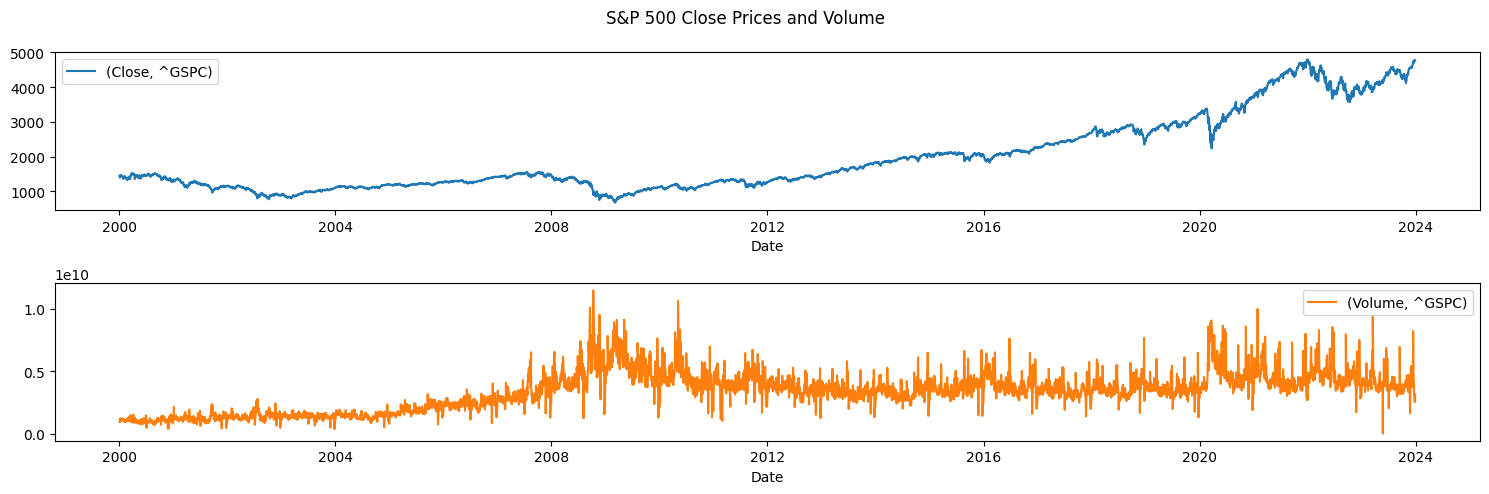

In [6]:
df = data[["Close", "Volume"]].copy()
df2 = data2[["Close", "Volume"]].copy()
fig, ax = plt.subplots(figsize=(15, 5))
df.plot(subplots=True, title="S&P 500 Close Prices and Volume", ax=ax)
plt.tight_layout()
plt.show()

In [7]:
df.columns = ["Close", "Volume"]
df2.columns = ["Close", "Volume"]

In [8]:
df[df["Volume"] == 0]
df2[df2["Volume"] == 0]

,Close,Volume
Date,,


In [9]:
print(df[df["Volume"] == 0].count())
df["Volume"] = df["Volume"].replace(0, np.nan)
df["Volume"] = df["Volume"].interpolate(method="linear")
print(df[df["Volume"] == 0].count())

Close     1
Volume    1
dtype: int64
Close     0
Volume    0
dtype: int64


In [10]:
print(df2[df2["Volume"] == 0].count())
df2["Volume"] = df2["Volume"].replace(0, np.nan)
df2["Volume"] = df2["Volume"].interpolate(method='linear')
print(df2[df2["Volume"] == 0].count())

Close     0
Volume    0
dtype: int64
Close     0
Volume    0
dtype: int64


In [11]:
window = 21

df["Log_Ret"] = np.log(df["Close"] / df["Close"].shift(1)).copy()

df["Volatility"] = (df["Log_Ret"].rolling(window=window).std() * np.sqrt(252)).copy()
df['Vol_Diff'] = df['Volatility'].diff()
log_vol_chg_coef = 1e-9
df["Log_Vol_Chg"] = np.log(
    (df["Volume"] + 1e-9) / (df["Volume"].shift(1) + 1e-9)
).copy()


df.head()

,Close,Volume,Log_Ret,Volatility,Vol_Diff,Log_Vol_Chg
Date,,,,,,
2000-01-03,1455.219971,9.318000e+08,NaN,NaN,NaN,NaN
2000-01-04,1399.420044,1.009000e+09,-0.039099,NaN,NaN,0.079597
2000-01-05,1402.109985,1.085500e+09,0.001920,NaN,NaN,0.073081
2000-01-06,1403.449951,1.092300e+09,0.000955,NaN,NaN,0.006245
2000-01-07,1441.469971,1.225200e+09,0.026730,NaN,NaN,0.114819


In [12]:
df2["Log_Ret"] = np.log(df2["Close"] / df2["Close"].shift(1)).copy()
df2["Volatility"] = (df2["Log_Ret"].rolling(window=window).std() * np.sqrt(252)).copy()
df2['Vol_Diff'] = df2['Volatility'].diff()
log_vol_chg_coef = 1e-9
df2["Log_Vol_Chg"] = np.log(
    (df2["Volume"] + 1e-9) / (df2["Volume"].shift(1) + 1e-9)
).copy()
df2.head()

,Close,Volume,Log_Ret,Volatility,Vol_Diff,Log_Vol_Chg
Date,,,,,,
2024-01-02,4742.830078,3743050000,NaN,NaN,NaN,NaN
2024-01-03,4704.810059,3950760000,-0.008049,NaN,NaN,0.054007
2024-01-04,4688.680176,3715480000,-0.003434,NaN,NaN,-0.061400
2024-01-05,4697.240234,3844370000,0.001824,NaN,NaN,0.034102
2024-01-08,4763.540039,3742320000,0.014016,NaN,NaN,-0.026904


In [13]:
df.dropna(inplace=True)
df2.dropna(inplace=True)

In [14]:
print(df.isna().sum())
# df.interpolate(inplace=True)
# print(df.isna().sum())

print(df2.isna().sum())
# df2.interpolate(inplace=True)
# print(df2.isna().sum())

Close          0
Volume         0
Log_Ret        0
Volatility     0
Vol_Diff       0
Log_Vol_Chg    0
dtype: int64
Close          0
Volume         0
Log_Ret        0
Volatility     0
Vol_Diff       0
Log_Vol_Chg    0
dtype: int64


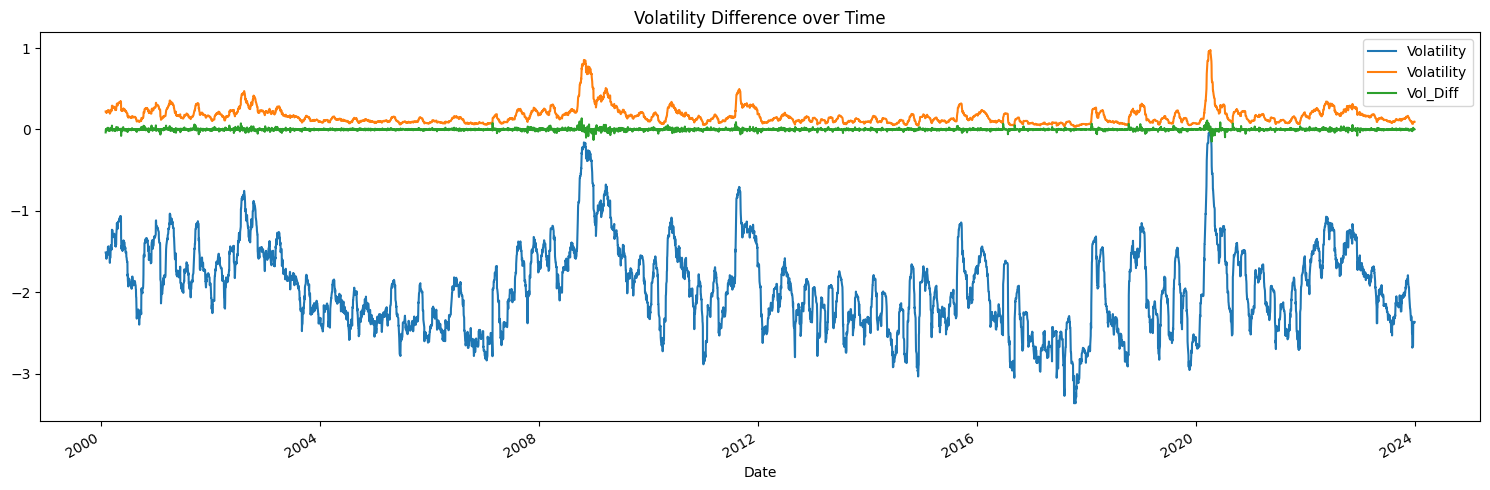

In [15]:
fig, ax = plt.subplots(figsize=(15, 5))
np.log(df["Volatility"]).plot(title="Log Volatility over Time", ax=ax)
df["Volatility"].plot(title="Volatility over Time", ax=ax)
df['Vol_Diff'].plot(title="Volatility Difference over Time", ax=ax)
plt.legend()
plt.tight_layout()

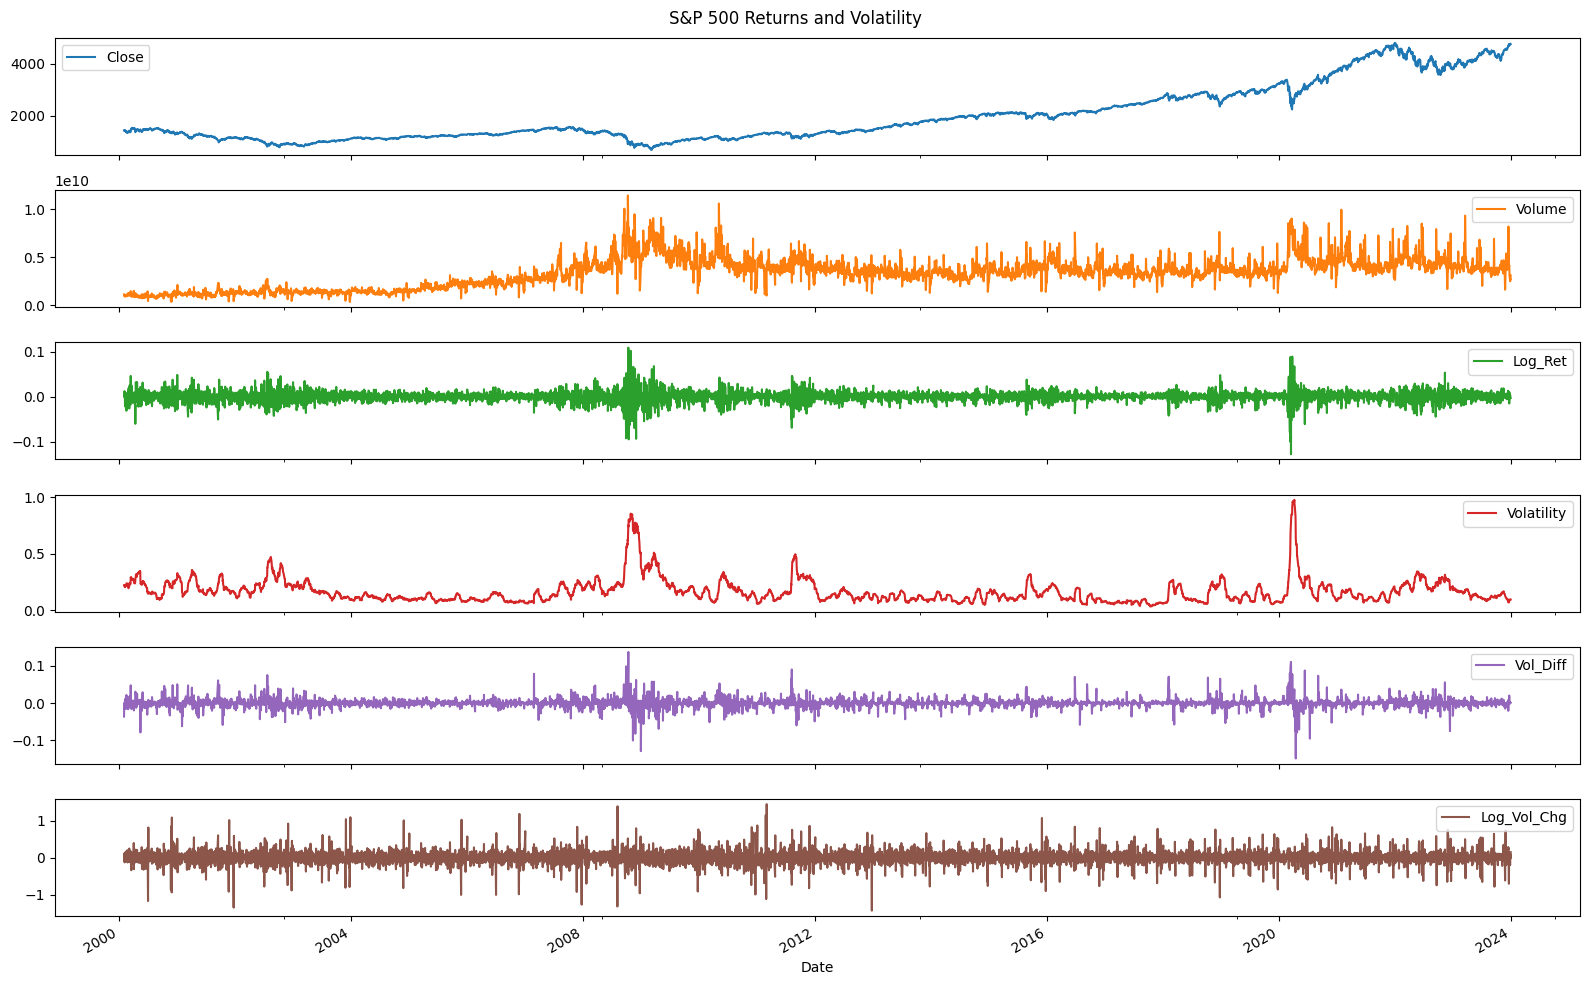

In [16]:
df.plot(subplots=True, title="S&P 500 Returns and Volatility", figsize=(16, 10))
plt.tight_layout()
plt.show()

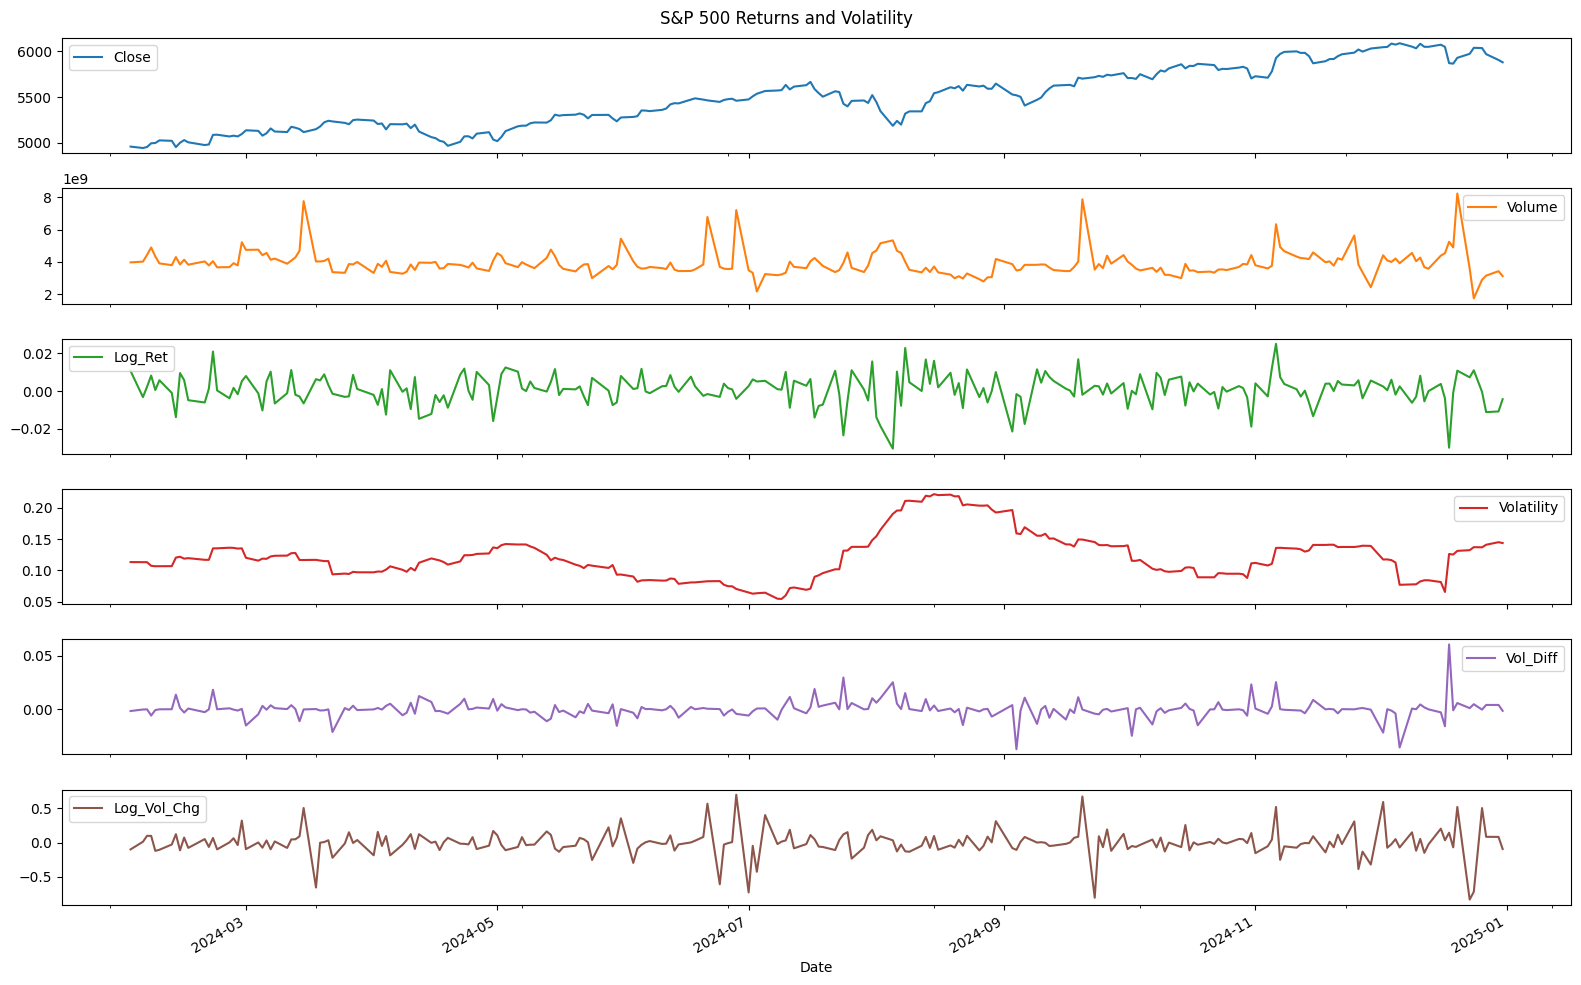

In [17]:
df2.plot(subplots=True, title="S&P 500 Returns and Volatility", figsize=(16, 10))
plt.tight_layout()
plt.show()

In [18]:
for col in df.columns[:]:
    print(f"{col} - Mean: {df[col].mean()}, Std: {df[col].std()}")
    print("ADF Test:")
    result = adfuller(df[col])
    print(f"\tADF Statistic: {result[0]}")
    print(f"\tp-value: {result[1]}")
    print(f"\tUsed Lag: {result[2]}")
    print(f"\tnobs: {result[3]}")
    # print(f"\tCritical Values:")
    # for key, value in result[4].items():
    #     print(f"\t   {key}: {value}")
    # print("\n")

Close - Mean: 1975.596325582122, Std: 1062.7526406705585
ADF Test:
	ADF Statistic: 1.571689726080348
	p-value: 0.9977701074858577
	Used Lag: 32
	nobs: 5982
Volume - Mean: 3335640789.6924357, Std: 1505889501.5383291
ADF Test:
	ADF Statistic: -3.058757823661956
	p-value: 0.029759700548931598
	Used Lag: 32
	nobs: 5982
Log_Ret - Mean: 0.00020271742121716942, Std: 0.012365603586544505
ADF Test:
	ADF Statistic: -18.588491657855812
	p-value: 2.0745862127798388e-30
	Used Lag: 17
	nobs: 5997
Volatility - Mean: 0.1657104388721503, Std: 0.10779594583807435
ADF Test:
	ADF Statistic: -6.669965628273028
	p-value: 4.614383837915483e-09
	Used Lag: 29
	nobs: 5985
Vol_Diff - Mean: -2.7065940321815153e-05, Std: 0.01151182444939982
ADF Test:
	ADF Statistic: -15.124545658525648
	p-value: 7.378571551700123e-28
	Used Lag: 28
	nobs: 5986
Log_Vol_Chg - Mean: 0.0001831919822518654, Std: 0.18606378293613174
ADF Test:
	ADF Statistic: -21.814669427710903
	p-value: 0.0
	Used Lag: 31
	nobs: 5983


In [20]:
def create_sequences(
    data: pd.DataFrame,
    lookback: int,
    horizon: int,
    feature_cols: list[str] = ["Vol_Diff"],
) -> tuple[np.ndarray, np.ndarray]:
    """Create sequences of data for time series forecasting.

    Args:
        data (pd.DataFrame): The input data containing features.
        lookback (int): The number of past timesteps to include in each input sequence.
        horizon (int): The number of future timesteps to predict.

    Returns:
        Tuple[np.ndarray, np.ndarray]: The input sequences (X) and the corresponding targets (y).
    """
    X, y = [], []

    data_values = data[feature_cols].values

    for i in range(len(data) - lookback - horizon):
        window = data_values[i : i + lookback]
        future_window = data_values[i + lookback : i + lookback + horizon, 0]

        X.append(window)
        y.append(future_window)

    return np.array(X), np.array(y)


HORIZON = 5
LOOKBACK = 60
X_raw, y_raw = create_sequences(df, lookback=LOOKBACK, horizon=HORIZON)
X_raw2, y_raw2 = create_sequences(df2, lookback=LOOKBACK, horizon=HORIZON)

print(f"X shape: {X_raw.shape}  (Samples, Timesteps, Features)")
print(f"y shape: {y_raw.shape}  (Samples, Horizon)")

print(f"X2 shape: {X_raw2.shape}  (Samples, Timesteps, Features)")
print(f"y2 shape: {y_raw2.shape}  (Samples, Horizon)")

X shape: (5950, 60, 1)  (Samples, Timesteps, Features)
y shape: (5950, 5)  (Samples, Horizon)
X2 shape: (165, 60, 1)  (Samples, Timesteps, Features)
y2 shape: (165, 5)  (Samples, Horizon)


In [21]:
n_sep = int(0.8 * X_raw.shape[0])
X_train, X_test = X_raw[:n_sep], X_raw[n_sep:]
y_train, y_test = y_raw[:n_sep], y_raw[n_sep:]

X_scaler = StandardScaler()
y_scaler = StandardScaler()

X_scaler.fit(X_train.reshape(-1, X_train.shape[-1]))
y_scaler.fit(y_train.reshape(-1, y_train.shape[-1]))

X_train_scaled = X_scaler.transform(
    X_train.reshape(-1, X_train.shape[-1])
).reshape(X_train.shape)

X_test_scaled = X_scaler.transform(
    X_test.reshape(-1, X_test.shape[-1])
).reshape(X_test.shape)

y_train_scaled = y_scaler.transform(
    y_train.reshape(-1, y_train.shape[-1])
).reshape(y_train.shape)

y_test_scaled = y_scaler.transform(
    y_test.reshape(-1, y_test.shape[-1])
).reshape(y_test.shape)

print("Data shapes:")
print("Raw Data:")
print(f"Training set: X={X_train.shape}, y={y_train.shape}")
print(f"Test set: X={X_test.shape}, y={y_test.shape}")

print("Scaled Data:")
print(f"Training set: X={X_train_scaled.shape}, y={y_train_scaled.shape}")
print(f"Test set: X={X_test_scaled.shape}, y={y_test_scaled.shape}")

Data shapes:
Raw Data:
Training set: X=(4760, 60, 1), y=(4760, 5)
Test set: X=(1190, 60, 1), y=(1190, 5)
Scaled Data:
Training set: X=(4760, 60, 1), y=(4760, 5)
Test set: X=(1190, 60, 1), y=(1190, 5)


In [22]:
X_test2, y_test2 = X_raw2, y_raw2

# X_scaler2 = StandardScaler()
# y_scaler2 = StandardScaler()

# X_scaler.fit(X_test2.reshape(-1, X_test2.shape[-1]))
# y_scaler.fit(y_test2.reshape(-1, y_test2.shape[-1]))

X_test_scaled2 = X_scaler.transform(
    X_test2.reshape(-1, X_test2.shape[-1])
).reshape(X_test2.shape)

y_test_scaled2 = y_scaler.transform(
    y_test2.reshape(-1, y_test2.shape[-1])
).reshape(y_test2.shape)

print("Data shapes:")
print("Raw Data:")
print(f"Test set: X={X_test2.shape}, y={y_test2.shape}")

print("Scaled Data:")
print(f"Test set: X={X_test_scaled2.shape}, y={y_test_scaled2.shape}")

Data shapes:
Raw Data:
Test set: X=(165, 60, 1), y=(165, 5)
Scaled Data:
Test set: X=(165, 60, 1), y=(165, 5)


In [23]:
INPUT_SHAPE = (X_train.shape[1], X_train.shape[2])
OUTPUT_SIZE = y_train.shape[1]

print(f"Input shape: {INPUT_SHAPE}")
print(f"Output size: {OUTPUT_SIZE}")

Input shape: (60, 1)
Output size: 5


In [24]:
model = Sequential(
    [
        Input(shape=INPUT_SHAPE),
        GRU(units=64, return_sequences=False, activation="tanh", recurrent_dropout=0.0),
        Dropout(0.3),
        Dense(32, activation="relu"),
        Dense(OUTPUT_SIZE, activation="linear"),
    ]
)

model.compile(optimizer="adam", loss="mse", metrics=["mae"])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,109 (59.02 KB)

 Trainable params: 15,109 (59.02 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, verbose=1)
]

In [26]:
history = model.fit(
    X_train_scaled, y_train_scaled,
    validation_data=(X_test_scaled, y_test_scaled),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.9812 - mae: 0.5393 - val_loss: 1.4496 - val_mae: 0.6100 - learning_rate: 0.0010
Epoch 2/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.9746 - mae: 0.5442 - val_loss: 1.4404 - val_mae: 0.6126 - learning_rate: 0.0010
Epoch 3/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.9714 - mae: 0.5456 - val_loss: 1.4372 - val_mae: 0.6105 - learning_rate: 0.0010
Epoch 4/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.9582 - mae: 0.5468 - val_loss: 1.3689 - val_mae: 0.6184 - learning_rate: 0.0010
Epoch 5/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.9395 - mae: 0.5477 - val_loss: 1.3968 - val_mae: 0.6221 - learning_rate: 0.0010
Epoch 6/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.9191 - mae: 0.5461 - val_loss: 1.3878 - val_mae: 0.6184 - learning_rate: 0.0010
Epoch 7/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.9121 - mae: 0.5455 - val_loss: 1.3740 - val_mae: 0.6200 - learning_rate:

In [ ]:
# model.save("../Data/model/sp500_gru_vol_change.keras")

In [31]:
y_pred_scaled: np.ndarray = model.predict(X_test_scaled)


y_pred = y_scaler.inverse_transform(
    y_pred_scaled.reshape(-1, y_test.shape[-1])
).reshape(y_pred_scaled.shape)

y_true = y_test


y_pred_df = pd.DataFrame(
    y_pred[:, 0], index=df.index[LOOKBACK + n_sep : -HORIZON], columns=["Predicted_Vol_change"]
)
y_true_df = pd.DataFrame(
    y_true[:, 0], index=df.index[LOOKBACK + n_sep : -HORIZON], columns=["Actual_Vol_change"]
)

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


<Figure size 1400x600 with 0 Axes>

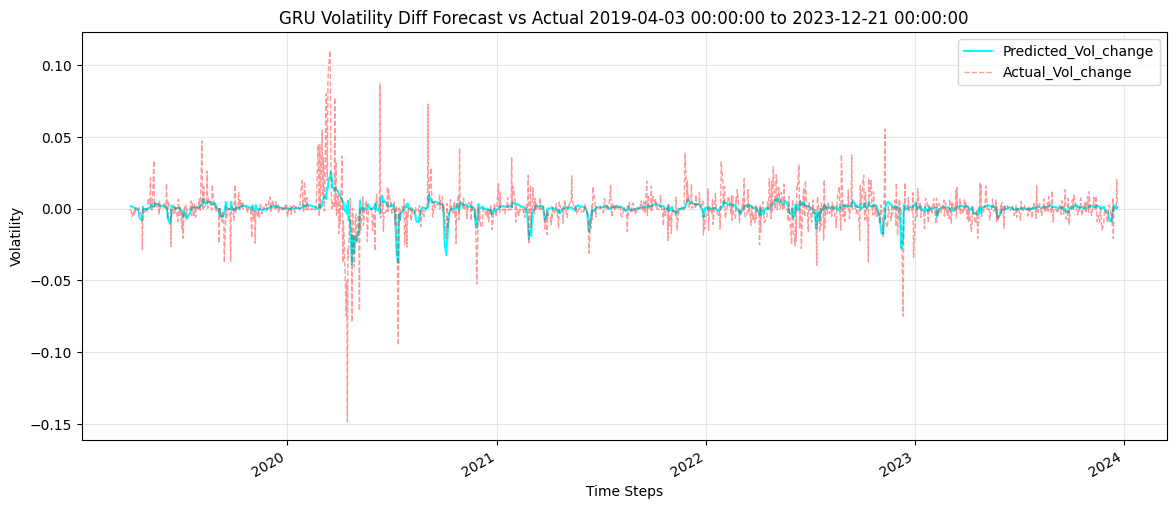

Sample 10 Actual 21-Day Vol:    [ 0.00062096 -0.00105843 -0.00590559 -0.02860227  0.00091466]...
Sample 10 Predicted 21-Day Vol: [-0.00390121 -0.00505121 -0.00564338 -0.00513991 -0.00441897]...


In [32]:
plt.figure(figsize=(14, 6))

limit = 2000

fig, ax = plt.subplots(figsize=(14, 6))
y_pred_df.plot(
    ax=ax, color="cyan", legend=True
)
y_true_df.plot(
    ax=ax, color="red", linewidth=1,linestyle="--", legend=True, alpha=0.4
)

plt.title(f"GRU Volatility Diff Forecast vs Actual {y_pred_df.index[0]} to {y_pred_df.index[-1]}")
plt.xlabel("Time Steps")
plt.ylabel("Volatility")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Sample 10 Actual {window}-Day Vol:    {y_test[10][:5]}...")
print(f"Sample 10 Predicted {window}-Day Vol: {y_pred[10][:5]}...")

In [33]:
y_pred_scaled2 = model.predict(X_test_scaled2)

y_pred2 = y_scaler.inverse_transform(
    y_pred_scaled2.reshape(-1, y_test2.shape[-1])
).reshape(y_test2.shape)
y_true2 = y_test2

y_pred2_df = pd.DataFrame(
    y_pred2[:, 0],
    index=df2.index[LOOKBACK:-HORIZON],
    columns=["Predicted_Vol_change"],
)
y_true2_df = pd.DataFrame(
    y_true2[:, 0], index=df2.index[LOOKBACK:-HORIZON], columns=["Actual_Vol_change"]
)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


<Figure size 1400x600 with 0 Axes>

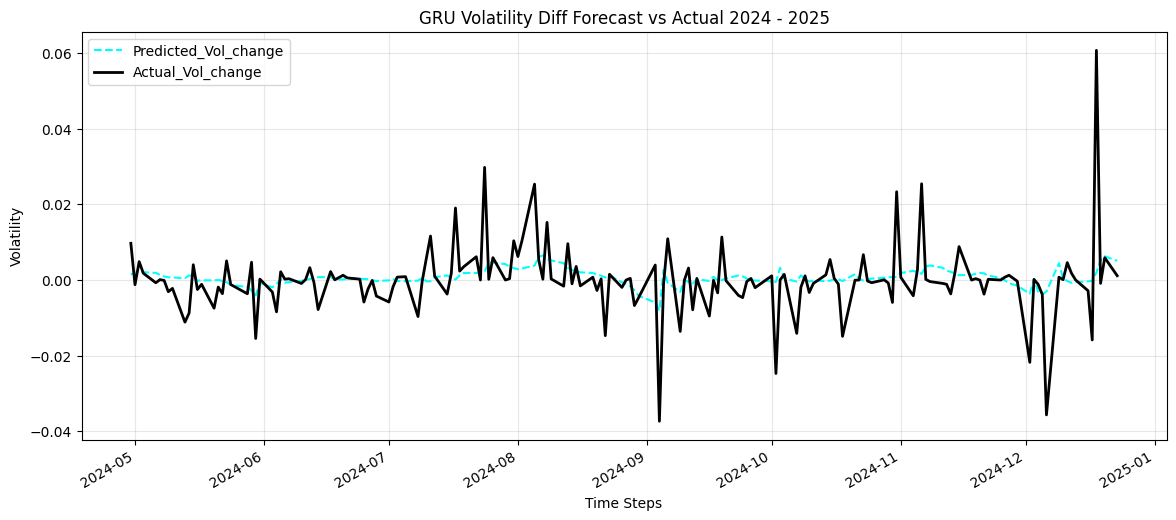

Actual    [-0.00873654  0.00403359 -0.00251372 -0.0011405  -0.00745287]...
Predicted [ 0.00120227  0.0003985  -0.0005068  -0.00089556 -0.00072972]...


In [34]:
plt.figure(figsize=(14, 6))

fig, ax = plt.subplots(figsize=(14, 6))

y_pred2_df.plot(ax=ax, label="Predicted Volatility (t+1)", color="cyan", linestyle="--")
y_true2_df.plot(ax=ax, label="Actual Volatility (t+1)", color="black", linewidth=2)

plt.title("GRU Volatility Diff Forecast vs Actual 2024 - 2025")
plt.xlabel("Time Steps")
plt.ylabel("Volatility")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
print(f"Actual    {y_true2[10][:5]}...")
print(f"Predicted {y_pred2[10][:5]}...")

In [36]:
print("=" * 60, f"Evaluating on {y_true_df.index[0]} to {y_true_df.index[-1]} Data", "=" * 60, sep="\n")
naive_mse = mean_squared_error(y_true_df[1:]["Actual_Vol_change"], y_true_df["Actual_Vol_change"].shift(1).dropna())
naive_mae = mean_absolute_error(y_true_df[1:]["Actual_Vol_change"], y_true_df["Actual_Vol_change"].shift(1).dropna())
naive_r2 = r2_score(y_true_df[1:]["Actual_Vol_change"], y_true_df["Actual_Vol_change"].shift(1).dropna())
print(f"Naive Baseline RMSE: {np.sqrt(naive_mse)}")
print(f"Naive Baseline MAE: {naive_mae}")
print(f"Naive Baseline R²: {naive_r2}")

print("-" * 40)

mse = mean_squared_error(y_true_df["Actual_Vol_change"], y_pred_df["Predicted_Vol_change"])
mae = mean_absolute_error(y_true_df["Actual_Vol_change"], y_pred_df["Predicted_Vol_change"])
r2 = r2_score(y_true_df["Actual_Vol_change"], y_pred_df["Predicted_Vol_change"])
print(f"Model RMSE: {np.sqrt(mse)}")
print(f"Model MAE: {mae}")
print(f"Model R²: {r2}")

print("=" * 60, f"Evaluating on {y_true2_df.index[0]} to {y_true2_df.index[-1]} Data (Out of scope)", "=" * 60, sep="\n")
naive_mse = mean_squared_error(y_true2_df[1:]["Actual_Vol_change"], y_true2_df["Actual_Vol_change"].shift(1).dropna())
naive_mae = mean_absolute_error(y_true2_df[1:]["Actual_Vol_change"], y_true2_df["Actual_Vol_change"].shift(1).dropna())
naive_r2 = r2_score(y_true2_df[1:]["Actual_Vol_change"], y_true2_df["Actual_Vol_change"].shift(1).dropna())
print(f"Naive Baseline RMSE: {np.sqrt(naive_mse)}")
print(f"Naive Baseline MAE: {naive_mae}")
print(f"Naive Baseline R²: {naive_r2}")

print("-" * 40)

mse = mean_squared_error(y_true2_df["Actual_Vol_change"], y_pred2_df["Predicted_Vol_change"])
mae = mean_absolute_error(y_true2_df["Actual_Vol_change"], y_pred2_df["Predicted_Vol_change"])
r2 = r2_score(y_true2_df["Actual_Vol_change"], y_pred2_df["Predicted_Vol_change"])
print(f"Model RMSE: {np.sqrt(mse)}")
print(f"Model MAE: {mae}")
print(f"Model R²: {r2}")

Evaluating on 2019-04-03 00:00:00 to 2023-12-21 00:00:00 Data
Naive Baseline RMSE: 0.016689394609301283
Naive Baseline MAE: 0.00999742337149763
Naive Baseline R²: -0.49837588903052454
----------------------------------------
Model RMSE: 0.012496816351450052
Model MAE: 0.006744364232099821
Model R²: 0.15917937412031014
Evaluating on 2024-04-30 00:00:00 to 2024-12-23 00:00:00 Data (Out of scope)
Naive Baseline RMSE: 0.013523435408387819
Naive Baseline MAE: 0.008361708875187163
Naive Baseline R²: -1.0775303066213877
----------------------------------------
Model RMSE: 0.00879527163920783
Model MAE: 0.0049975509150087215
Model R²: 0.12160408269698042


In [28]:
# Y: differentiated in Volatility
# X: 3 features: Close, Volume, Volatility Change
# 60 Lookback, 5 Horizon
# GRU Model with 64 units, Dropout 0.3, Dense 32
# Trained for ~50 epochs with EarlyStopping and ReduceLROnPlateau
# ============================================================
# Evaluating on 2019-04-03 00:00:00 to 2023-12-21 00:00:00 Data
# ============================================================
# Naive Baseline RMSE: 0.016689394609301283
# Naive Baseline MAE: 0.00999742337149763
# Naive Baseline R²: -0.49837588903052454
# ----------------------------------------
# Model RMSE: 0.012591713524804182
# Model MAE: 0.006704807588906878
# Model R²: 0.14636099620438792
# ============================================================
# Evaluating on 2024-04-30 00:00:00 to 2024-12-23 00:00:00 Data (Out of scope)
# ============================================================
# Naive Baseline RMSE: 0.013523435408387819
# Naive Baseline MAE: 0.008361708875187163
# Naive Baseline R²: -1.0775303066213877
# ----------------------------------------
# Model RMSE: 0.009080688718547152
# Model MAE: 0.005483003387696456
# Model R²: 0.0636690661889392

In [37]:
# y_true_df['Actual_Vol_change']
y_true_df["actual_volatility"] = df.loc[(df.index >= y_true_df.index[0]) & (df.index <= y_true_df.index[-1]),'Volatility'].shift(1) + y_true_df['Actual_Vol_change']
y_true_df.dropna(inplace=True)

y_pred_df["computed_volatility"] = df.loc[(df.index >= y_pred_df.index[0]) & (df.index <= y_pred_df.index[-1]),'Volatility'].shift(1) + y_pred_df['Predicted_Vol_change']
y_pred_df.dropna(inplace=True)

y_true2_df["actual_volatility"] = df2.loc[(df2.index >= y_true2_df.index[0]) & (df2.index <= y_true2_df.index[-1]),'Volatility'].shift(1) + y_true2_df['Actual_Vol_change']
y_true2_df.dropna(inplace=True)

y_pred2_df["computed_volatility"] = df2.loc[(df2.index >= y_pred2_df.index[0]) & (df2.index <= y_pred2_df.index[-1]),'Volatility'].shift(1) + y_pred2_df['Predicted_Vol_change']
y_pred2_df.dropna(inplace=True)

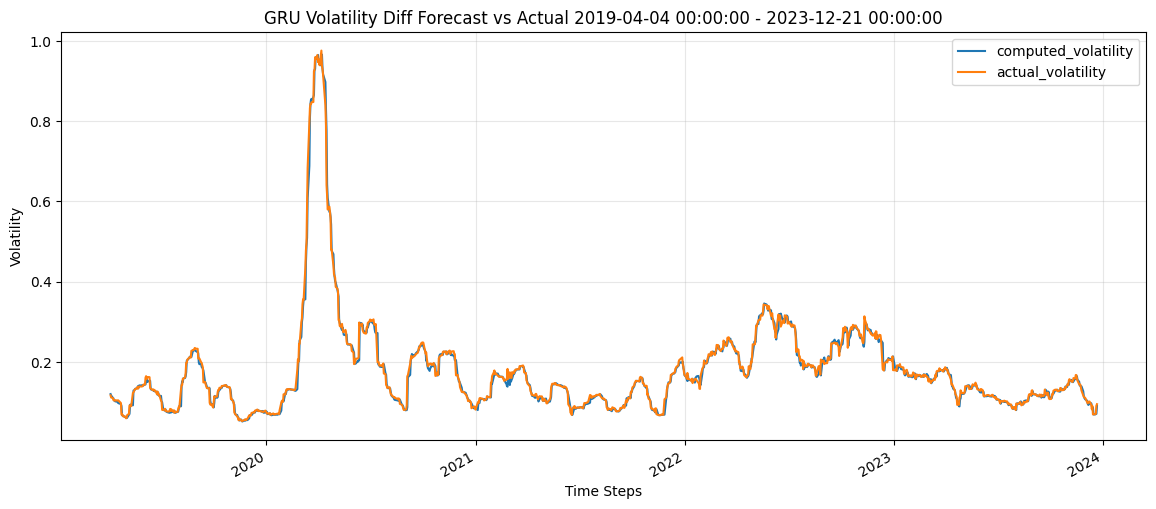

In [430]:
fig, ax = plt.subplots(figsize=(14, 6))

y_pred_df[["computed_volatility"]].plot(ax=ax)
y_true_df[["actual_volatility"]].plot(ax=ax)

plt.title(f"GRU Volatility Diff Forecast vs Actual {y_true_df.index[0]} - {y_true_df.index[-1]}")
plt.xlabel("Time Steps")
plt.ylabel("Volatility")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


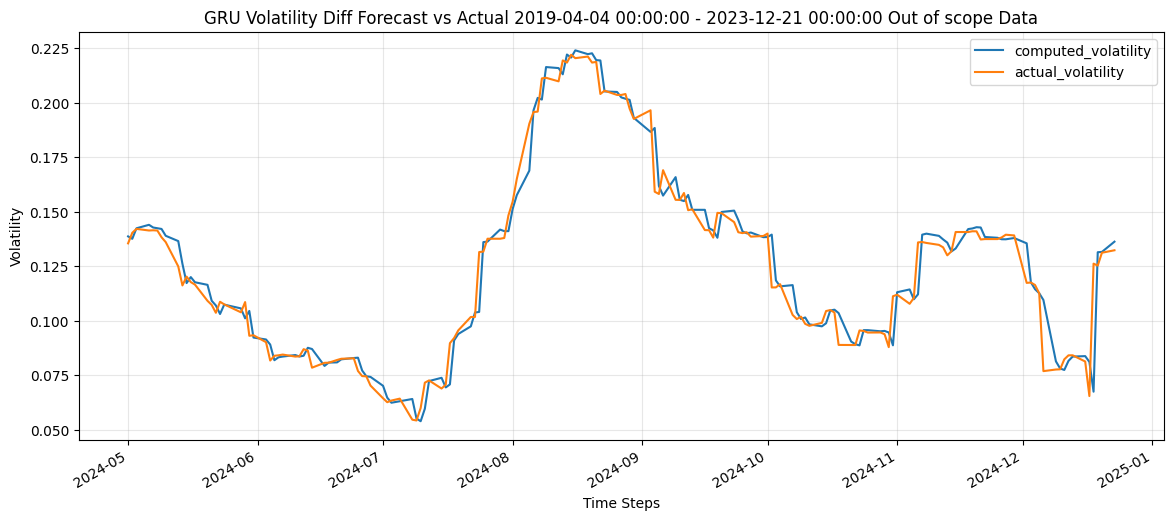

In [38]:
fig, ax = plt.subplots(figsize=(14, 6))

y_pred2_df[["computed_volatility"]].plot(ax=ax)
y_true2_df[["actual_volatility"]].plot(ax=ax,)

plt.title(f"GRU Volatility Diff Forecast vs Actual {y_true_df.index[0]} - {y_true_df.index[-1]} Out of scope Data")
plt.xlabel("Time Steps")
plt.ylabel("Volatility")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [432]:
print("=" * 60, f"Evaluating on {y_true_df.index[0]} to {y_true_df.index[-1]} Data", "=" * 60, sep="\n")
naive_mse = mean_squared_error(y_true_df.iloc[1:]["actual_volatility"], y_true_df["actual_volatility"].shift(1).dropna())
naive_mae = mean_absolute_error(y_true_df["actual_volatility"][1:], y_true_df["actual_volatility"].shift(1).dropna())
naive_r2 = r2_score(y_true_df["actual_volatility"][1:], y_true_df["actual_volatility"].shift(1).dropna())
print(f"Naive Baseline RMSE: {np.sqrt(naive_mse)}")
print(f"Naive Baseline MAE: {naive_mae}")
print(f"Naive Baseline R²: {naive_r2}")

print("-" * 40)

mse = mean_squared_error(y_true_df["actual_volatility"], y_pred_df["computed_volatility"])
mae = mean_absolute_error(y_true_df["actual_volatility"], y_pred_df["computed_volatility"])
r2 = r2_score(y_true_df["actual_volatility"], y_pred_df["computed_volatility"])
print(f"Model RMSE: {np.sqrt(mse)}")
print(f"Model MAE: {mae}")
print(f"Model R²: {r2}")

print("=" * 60, f"Evaluating on {y_true2_df.index[0]} to {y_true2_df.index[-1]} Data (Out of scope)", "=" * 60, sep="\n")
naive_mse = mean_squared_error(y_true2_df["actual_volatility"][1:], y_true2_df["actual_volatility"].shift(1).dropna())
naive_mae = mean_absolute_error(y_true2_df["actual_volatility"][1:], y_true2_df["actual_volatility"].shift(1).dropna())
naive_r2 = r2_score(y_true2_df["actual_volatility"][1:], y_true2_df["actual_volatility"].shift(1).dropna())
print(f"Naive Baseline RMSE: {np.sqrt(naive_mse)}")
print(f"Naive Baseline MAE: {naive_mae}")
print(f"Naive Baseline R²: {naive_r2}")

print("-" * 40)

mse = mean_squared_error(y_true2_df["actual_volatility"], y_pred2_df["computed_volatility"])
mae = mean_absolute_error(y_true2_df["actual_volatility"], y_pred2_df["computed_volatility"])
r2 = r2_score(y_true2_df["actual_volatility"], y_pred2_df["computed_volatility"])
print(f"Model RMSE: {np.sqrt(mse)}")
print(f"Model MAE: {mae}")
print(f"Model R²: {r2}")

Evaluating on 2019-04-04 00:00:00 to 2023-12-21 00:00:00 Data
Naive Baseline RMSE: 0.013639584391456966
Naive Baseline MAE: 0.006705147430988082
Naive Baseline R²: 0.9882460461876016
----------------------------------------
Model RMSE: 0.0125970044348247
Model MAE: 0.0067101918727636625
Model R²: 0.9899679192869459
Evaluating on 2024-05-01 00:00:00 to 2024-12-23 00:00:00 Data (Out of scope)
Naive Baseline RMSE: 0.009410656856777767
Naive Baseline MAE: 0.004917446978749881
Naive Baseline R²: 0.9494690270070534
----------------------------------------
Model RMSE: 0.009074437112796879
Model MAE: 0.005455134557359517
Model R²: 0.952749338706042


In [ ]:
# Y:diff Volatility + previous Volatility
# X: 3 features: Close, Volume, Volatility Change
# 60 Lookback, 5 Horizon
# GRU Model with 64 units, Dropout 0.3, Dense 32
# Trained for ~50 epochs with EarlyStopping and ReduceLROnPlateau
# ============================================================
# Evaluating on 2019-04-04 00:00:00 to 2023-12-21 00:00:00 Data
# ============================================================
# Naive Baseline RMSE: 0.013639584391456966
# Naive Baseline MAE: 0.006705147430988082
# Naive Baseline R²: 0.9882460461876016
# ----------------------------------------
# Model RMSE: 0.0125970044348247
# Model MAE: 0.0067101918727636625
# Model R²: 0.9899679192869459
# ============================================================
# Evaluating on 2024-05-01 00:00:00 to 2024-12-23 00:00:00 Data (Out of scope)
# ============================================================
# Naive Baseline RMSE: 0.009410656856777767
# Naive Baseline MAE: 0.004917446978749881
# Naive Baseline R²: 0.9494690270070534
# ----------------------------------------
# Model RMSE: 0.009074437112796879
# Model MAE: 0.005455134557359517
# Model R²: 0.952749338706042

In [39]:
print("=" * 60, f"Evaluating on {y_true_df.index[0]} to {y_true_df.index[-1]} Data (Out of scope)", "=" * 60, sep="\n")
actual_dir = np.sign(y_true_df["Actual_Vol_change"])
pred_dir = np.sign(y_pred_df["Predicted_Vol_change"])

directional_acc = (actual_dir == pred_dir).mean()
print(f"Directional Prediction Accuracy: {directional_acc:.2%}")

print("=" * 60, f"Evaluating on {y_true2_df.index[0]} to {y_true2_df.index[-1]} Data (Out of scope)", "=" * 60, sep="\n")
actual_dir = np.sign(y_true2_df["Actual_Vol_change"])
pred_dir = np.sign(y_pred2_df["Predicted_Vol_change"])

directional_acc = (actual_dir == pred_dir).mean()
print(f"Directional Prediction Accuracy: {directional_acc:.2%}")

Evaluating on 2019-04-04 00:00:00 to 2023-12-21 00:00:00 Data (Out of scope)
Directional Prediction Accuracy: 57.02%
Evaluating on 2024-05-01 00:00:00 to 2024-12-23 00:00:00 Data (Out of scope)
Directional Prediction Accuracy: 56.71%


In [30]:
# ============================================================
# Evaluating on 2019-04-04 00:00:00 to 2023-12-21 00:00:00 Data (Out of scope)
# ============================================================
# Directional Prediction Accuracy: 61.98%
# ============================================================
# Evaluating on 2024-05-01 00:00:00 to 2024-12-23 00:00:00 Data (Out of scope)
# ============================================================
# Directional Prediction Accuracy: 57.32%

In [40]:
print("=" * 60, f"Evaluating on {y_true_df.index[0]} to {y_true_df.index[-1]} Data (Out of scope)", "=" * 60, sep="\n")
max_error_model = np.max(np.abs(y_true_df["actual_volatility"] - y_pred_df["computed_volatility"]))
max_error_naive = np.max(np.abs(y_true_df["actual_volatility"][1:] - y_true_df["actual_volatility"].shift(1).dropna()))

print(f"Max Error (Model): {max_error_model}")
print(f"Max Error (Naive): {max_error_naive}")

print("=" * 60, f"Evaluating on {y_true2_df.index[0]} to {y_true2_df.index[-1]} Data (Out of scope)", "=" * 60, sep="\n")
max_error_model = np.max(np.abs(y_true2_df["actual_volatility"] - y_pred2_df["computed_volatility"]))
max_error_naive = np.max(np.abs(y_true2_df["actual_volatility"][1:] - y_true2_df["actual_volatility"].shift(1).dropna()))

print(f"Max Error (Model): {max_error_model}")
print(f"Max Error (Naive): {max_error_naive}")

Evaluating on 2019-04-04 00:00:00 to 2023-12-21 00:00:00 Data (Out of scope)
Max Error (Model): 0.14441073956405048
Max Error (Naive): 0.1482329812410218
Evaluating on 2024-05-01 00:00:00 to 2024-12-23 00:00:00 Data (Out of scope)
Max Error (Model): 0.058758444370117804
Max Error (Naive): 0.060761938787412664


In [ ]:
# ============================================================
# Evaluating on 2019-04-04 00:00:00 to 2023-12-21 00:00:00 Data (Out of scope)
# ============================================================
# Max Error (Model): 0.13701494005945747
# Max Error (Naive): 0.1482329812410218
# ============================================================
# Evaluating on 2024-05-01 00:00:00 to 2024-12-23 00:00:00 Data (Out of scope)
# ============================================================
# Max Error (Model): 0.0587709168748677
# Max Error (Naive): 0.060761938787412664

C:\Users\yahya\AppData\Local\Temp\ipykernel_4144\3638502299.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("^GSPC", start="2000-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


Split Date: 2019-03-21 00:00:00
                       Zero Mean - GARCH Model Results                        
Dep. Variable:                Log_Ret   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -6575.74
Distribution:                  Normal   AIC:                           13157.5
Method:            Maximum Likelihood   BIC:                           13176.9
                                        No. Observations:                 4812
Date:                Tue, Jan 13 2026   Df Residuals:                     4812
Time:                        00:44:26   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega          0.0191  4.8

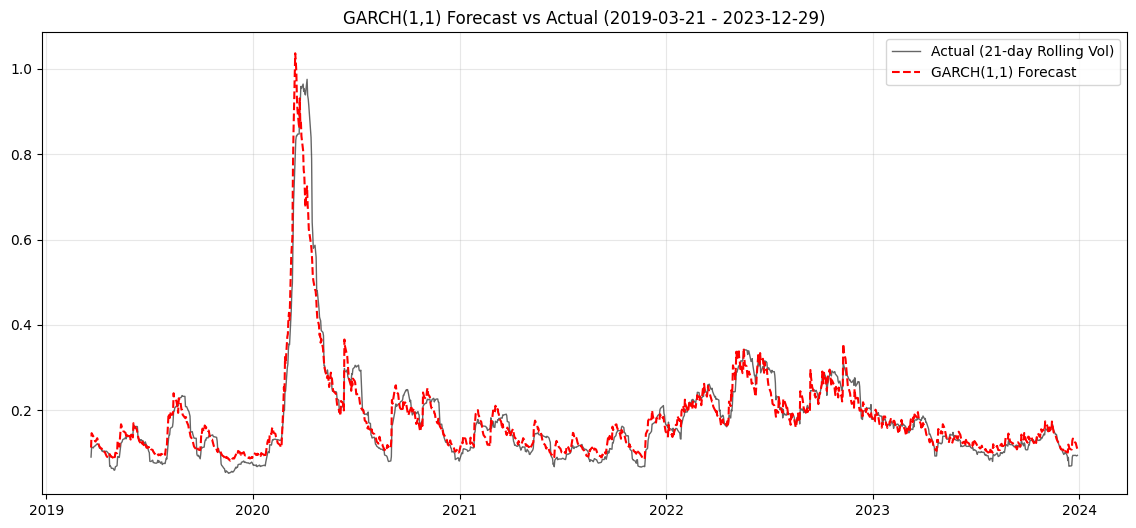

In [74]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ---------------------------------------------------------
# 1. Data Setup
# ---------------------------------------------------------
data = yf.download("^GSPC", start="2000-01-01", end="2024-01-01")
df = data[["Close"]].copy()

# Log Returns
df["Log_Ret"] = np.log(df["Close"] / df["Close"].shift(1))

# Target: 21-day Rolling Volatility * sqrt(252)
window = 21
df["Target_Vol"] = df["Log_Ret"].rolling(window=window).std() * np.sqrt(252)
df.dropna(inplace=True)

# ---------------------------------------------------------
# 2. Correct Train / Test Split Logic
# ---------------------------------------------------------
n_total = len(df)
n_train = int(0.8 * n_total)

# Scale returns by 100 for GARCH numerical stability
returns = df["Log_Ret"] * 100

# Identify the split date
split_date = returns.index[n_train]
print(f"Split Date: {split_date}")

# ---------------------------------------------------------
# 3. Fit GARCH(1,1) using 'last_obs'
# ---------------------------------------------------------
# CRITICAL FIX: We pass the FULL 'returns' series to the model,
# but we restrict fitting to the training set using 'last_obs'.
model = arch_model(returns, vol='Garch', p=1, q=1, mean='Zero', dist='Normal')

# Fit only on data up to the split_date
res = model.fit(last_obs=split_date, disp='off')

print(res.summary())

# ---------------------------------------------------------
# 4. Rolling Forecast
# ---------------------------------------------------------
# Now the model has access to the full timeline.
# We ask it to start forecasting FROM the split_date onwards.
forecasts = res.forecast(start=split_date, horizon=1, reindex=True)

# Extract variance forecast
# The forecast dataframe aligns with the input 'returns' index.
# We slice from the split_date to get the test set.
predicted_variance = forecasts.variance[split_date:]

# Convert GARCH Variance -> Annualized Volatility
# 1. Sqrt to get daily standard deviation
# 2. Divide by 100 to undo the scaling
# 3. Multiply by sqrt(252) to annualize
garch_vol_pred = np.sqrt(predicted_variance) / 100 * np.sqrt(252)

# Align with actuals
# Note: 'garch_vol_pred' at index t is the forecast for t+1 variance (usually).
# However, for simple comparison against rolling vol, we match timestamps.
test_actuals = df.loc[garch_vol_pred.index, "Target_Vol"]

# Drop NaNs that might appear at the very end or start of alignment
valid_data = pd.concat([test_actuals, garch_vol_pred], axis=1).dropna()
valid_data.columns = ["Actual", "Predicted"]

y_true = valid_data["Actual"]
y_pred = valid_data["Predicted"]

# ---------------------------------------------------------
# 5. Evaluation Metrics
# ---------------------------------------------------------
if len(y_true) == 0:
    print("Error: No overlapping data found. Check indices.")
else:
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print("=" * 60)
    print("GARCH(1,1) Performance (Out of Sample)")
    print("=" * 60)
    print(f"Naive RMSE: {mean_squared_error(y_true[1:], y_true.shift(1).dropna()):.5f}")
    print(f"Naive MAE: {mean_absolute_error(y_true[1:], y_true.shift(1).dropna()):.5f}")
    print(f"RMSE: {np.sqrt(mse):.5f}")
    print(f"MAE:  {mae:.5f}")
    print(f"R²:   {r2:.5f}")
    print("-" * 60)

    # ---------------------------------------------------------
    # 6. Visualization
    # ---------------------------------------------------------
    plt.figure(figsize=(14, 6))
    plt.plot(y_true, label="Actual (21-day Rolling Vol)", color="black", alpha=0.6, linewidth=1)
    plt.plot(y_pred, label="GARCH(1,1) Forecast", color="red", linestyle="--", linewidth=1.5)
    plt.title(f"GARCH(1,1) Forecast vs Actual ({y_true.index[0].date()} - {y_true.index[-1].date()})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()